# Ablation IMV — IMDb / DistilBERT

Architectural ablation of DistilBERT on IMDb sentiment, scored with IMV.

**This is a new run, not a replication.** The published IMDb figure used the full
25k/25k split at 512 tokens for 3 epochs; reproducing that on one machine is
roughly 25-30 hours, and identical seeds do not give identical floats across
MPS/CUDA/CPU anyway. This notebook runs a smaller, fully documented configuration
end to end: download, ablate, train, predict, score.

**Pipeline**: download IMDb from the Hub -> tokenise -> apply five architectural
variants -> train each over ten seeds -> compute the pairwise IMV matrix.

The `NoNorm` variant is expected to fall *below the chance floor*. That is not a
weak result, it is a calibration collapse: replacing LayerNorm with Identity
leaves the residual stream unnormalised and the softmax saturates confidently
wrong. IMV has no equivalent coin there, so `get_w` returns NaN and we report
`information_deficit` in nats instead. This extreme variant uses float64 because
its unnormalised residual gradients can overflow float32; the architecture and
training schedule remain unchanged.

Downloaded data, restart predictions, and optional exports stay outside the
repository under `~/.cache`; only the executed notebook is committed.

Requires the `deep-learning` extra plus `transformers` and `datasets`.
Full documentation: `documentation/examples/ablation_imv/imdb.md`.

In [1]:
import os
import sys
import tempfile
import time
import warnings
from pathlib import Path

_PATH_DISPLAY_ROOT = Path()

def relative_path(path, *, start=None):
    """Return a display-only path relative to an explicit local anchor."""
    anchor = Path(start) if start is not None else _PATH_DISPLAY_ROOT
    try:
        relative = os.path.relpath(Path(path).expanduser().resolve(),
                                   start=anchor.expanduser().resolve())
    except ValueError:  # Paths on different Windows drives cannot be relativized.
        relative = Path(path).name
    return Path(relative).as_posix()

def _relative_warning_text(message):
    text = str(message)
    roots = {Path.home(), Path(sys.prefix), Path(sys.base_prefix),
             _PATH_DISPLAY_ROOT, Path(tempfile.gettempdir())}
    for root in sorted(roots, key=lambda value: len(str(value)), reverse=True):
        absolute = str(root.expanduser().resolve())
        text = text.replace(absolute, relative_path(absolute))
    return text

def _show_relative_warning(message, category, filename, lineno, file=None, line=None):
    stream = file if file is not None else sys.stderr
    warning_text = _relative_warning_text(message)
    print(f"{relative_path(filename)}:{lineno}: {category.__name__}: {warning_text}", file=stream)

warnings.showwarning = _show_relative_warning

%matplotlib inline
CACHE = Path(os.environ.get("IMV_CACHE_HOME", Path.home() / ".cache" / "imv"))
DATA_HOME = Path(os.environ.get("IMV_DATA_CACHE", CACHE / "datasets")) / "huggingface"
os.environ.setdefault("HF_HOME", str(DATA_HOME))
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")  # reliable HTTPS in headless execution

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, DistilBertForSequenceClassification
from datasets import load_dataset

import imv
from imv import AblationIMV, information_deficit, ll
from imv.utils import plot_ablation_matrix, save_figure

# Fail fast if Jupyter is attached to a different installation of imv.
_HERE = Path().resolve()
REPOSITORY_ROOT = next((path for path in (_HERE, *_HERE.parents)
                        if (path / "pyproject.toml").is_file()
                        and (path / "src" / "imv").is_dir()), None)
if REPOSITORY_ROOT is None:
    raise RuntimeError("Run this notebook from inside the imv repository checkout.")
_PATH_DISPLAY_ROOT = REPOSITORY_ROOT
IMV_SOURCE = Path(imv.__file__).resolve().parent
EXPECTED_IMV_SOURCE = (REPOSITORY_ROOT / "src" / "imv").resolve()
if IMV_SOURCE != EXPECTED_IMV_SOURCE:
    raise RuntimeError("Expected repository package at "
                       f"{relative_path(EXPECTED_IMV_SOURCE)}, imported "
                       f"{relative_path(IMV_SOURCE)}")

ARTIFACTS = Path(os.environ.get("IMV_ARTIFACT_CACHE", CACHE / "notebook_artifacts")) / "ablation_imv_imdb"
RESULTS = ARTIFACTS / "results"; RESULTS.mkdir(parents=True, exist_ok=True)
FIGURES = ARTIFACTS / "figures"; FIGURES.mkdir(parents=True, exist_ok=True)

SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]  # ten complete runs
N_TRAIN, N_TEST = 5000, 5000     # stratified subsample of IMDb's 25k/25k
MAX_LEN, BATCH, EPOCHS, LR, MAX_GRAD_NORM = 256, 16, 2, 2e-5, 1.0
CACHE_TAG = "v2_gradclip1"
NO_NORM_CACHE_TAG = "v3_gradclip1_float64"

# Device selection and reproducibility are delegated to this repository's package.
ablator = AblationIMV(random_seed=SEEDS[0])
DEVICE = ablator.device
print(f"imv {imv.__version__} from {relative_path(IMV_SOURCE)}")
print("package class:", f"{AblationIMV.__module__}.{AblationIMV.__name__}")


device: mps | torch 2.10.0


## 1. Download and tokenise

IMDb is fetched from the Hugging Face Hub into `~/.cache/imv/datasets/huggingface`
(or `IMV_DATA_CACHE/huggingface` when set). Nothing is stored in the repository.

In [2]:
raw = load_dataset("stanfordnlp/imdb", cache_dir=DATA_HOME)
                                         # datasets>=5 requires a namespaced repo id
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased", cache_dir=DATA_HOME)

class IMDbDataset(Dataset):
    """Dictionary batches expected by AblationIMV.train_and_evaluate."""
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return {"input_ids": self.encodings["input_ids"][index],
                "attention_mask": self.encodings["attention_mask"][index],
                "labels": self.labels[index]}

def encode(split, n, seed):
    """Class-balanced subsample, tokenised to fixed length."""
    frame = raw[split].to_pandas()
    per_class = n // 2
    parts = [frame[frame.label == c].sample(per_class, random_state=seed) for c in (0, 1)]
    frame = pd.concat(parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    enc = tokenizer(list(frame.text), truncation=True, padding="max_length",
                    max_length=MAX_LEN, return_tensors="pt")
    labels = torch.tensor(frame.label.values, dtype=torch.long)
    return IMDbDataset(enc, labels)

print({k: raw[k].num_rows for k in raw})


{'train': 25000, 'test': 25000, 'unsupervised': 50000}


## 2. Architectural variants

In [3]:
# Model-specific component surgery stays local; supported depth reduction uses
# the repository package directly.
def variant_original(model):
    return model

def variant_three_layers(model):
    return AblationIMV.reduce_bert_layers(model, num_layers_to_keep=3)

def variant_no_attention(model):
    for layer in model.distilbert.transformer.layer:
        layer.attention.q_lin = torch.nn.Identity()
        layer.attention.k_lin = torch.nn.Identity()
        layer.attention.v_lin = torch.nn.Identity()
    return model

def variant_no_ffn(model):
    for layer in model.distilbert.transformer.layer:
        layer.ffn = torch.nn.Identity()
    return model

def variant_no_norm(model):
    for layer in model.distilbert.transformer.layer:
        layer.sa_layer_norm = torch.nn.Identity()
        layer.output_layer_norm = torch.nn.Identity()
    # Removing every transformer norm can overflow float32 gradients.
    return model.double()

VARIANTS = {
    "Original": variant_original,
    "3Layers": variant_three_layers,
    "NoAttention": variant_no_attention,
    "NoFFN": variant_no_ffn,
    "NoNorm": variant_no_norm,
}


## 3. Training and prediction

The seed drives the data subsample, the classifier head initialisation and the batch order, so each seed is an independent replicate.

In [4]:
def train_and_predict(surgery, seed, train_ds, test_ds):
    """Fit one variant through this repository's AblationIMV trainer."""
    ablator.set_seed(seed)  # seed classifier-head initialisation
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = DistilBertForSequenceClassification.from_pretrained(
            "distilbert-base-uncased", num_labels=2, cache_dir=DATA_HOME)
    model = surgery(model)
    run = ablator.train_and_evaluate(
        model,
        DataLoader(train_ds, batch_size=BATCH, shuffle=True),
        DataLoader(test_ds, batch_size=64),
        num_epochs=EPOCHS,
        lr=LR,
        optimizer_class=torch.optim.AdamW,
        max_grad_norm=MAX_GRAD_NORM,
        seed=seed,
        verbose=False,
    )
    frame = run["test_predictions"].copy()
    del run, model
    if DEVICE.type == "mps": torch.mps.empty_cache()
    return frame


## 4. Run five variants over ten seeds

About 5 minutes per run, so roughly two hours for all 25 on Apple Silicon.

In [5]:
# Fifty DistilBERT runs take roughly 180 minutes, so this loop is
# restartable: a variant is reused only when its cached predictions validate.
def load_valid_predictions(path, expected_labels):
    if not path.exists():
        return None
    try:
        frame = pd.read_csv(path)
    except (OSError, ValueError, pd.errors.ParserError):
        return None
    expected_columns = ["Negative Probability", "Positive Probability",
                        "True Label", "Predicted Label"]
    if list(frame.columns) != expected_columns or len(frame) != len(expected_labels):
        return None
    probabilities = frame[expected_columns[:2]].to_numpy(float)
    labels = frame["True Label"].to_numpy(int)
    predicted = frame["Predicted Label"].to_numpy(int)
    if (not np.isfinite(probabilities).all()
            or np.any((probabilities < 0) | (probabilities > 1))
            or not np.allclose(probabilities.sum(axis=1), 1.0, atol=1e-6)
            or not np.array_equal(labels, expected_labels)
            or not np.array_equal(predicted, probabilities.argmax(axis=1))):
        return None
    return frame

def prediction_path(name, seed):
    tag = NO_NORM_CACHE_TAG if name == "NoNorm" else CACHE_TAG
    return RESULTS / f"predictions_{tag}_{name}_seed_{seed}.csv"

matrices, diagnostics = [], []
for seed in SEEDS:
    paths = {name: prediction_path(name, seed) for name in VARIANTS}
    test_ds = encode("test", N_TEST, seed)
    expected_labels = test_ds.labels.numpy()
    cached_frames = {name: load_valid_predictions(path, expected_labels)
                     for name, path in paths.items()}
    train_ds = (encode("train", N_TRAIN, seed)
                if any(frame is None for frame in cached_frames.values()) else None)
    frames = {}
    for name, surgery in VARIANTS.items():
        t0 = time.perf_counter()
        cached = cached_frames[name] is not None
        if cached:
            frames[name] = cached_frames[name]
        else:
            frames[name] = train_and_predict(surgery, seed, train_ds, test_ds)
            frames[name].to_csv(paths[name], index=False)
        y = frames[name]["True Label"].to_numpy(float)
        p = frames[name]["Positive Probability"].to_numpy(float)
        a = ll(y, p)
        diagnostics.append({"seed": seed, "variant": name, "geometric_mean_likelihood": a,
                            "information_deficit_nats": information_deficit(a),
                            "accuracy": float(((p > 0.5) == (y > 0.5)).mean()),
                            "minutes": float("nan") if cached else (time.perf_counter() - t0) / 60,
                            "cached": cached})
        note = "reused" if cached else f"{(time.perf_counter() - t0) / 60:.1f} min"
        print(f"  seed {seed} {name:<12} a={a:.5g} deficit={information_deficit(a):+.3f} "
              f"acc={diagnostics[-1]['accuracy']:.4f} ({note})")
    with warnings.catch_warnings(record=True):
        matrices.append(AblationIMV.calculate_imv_matrix(frames))

diag = pd.DataFrame(diagnostics)
diag.to_csv(RESULTS / "imdb_variant_diagnostics.csv", index=False)
diag.groupby("variant")[["geometric_mean_likelihood","information_deficit_nats","accuracy"]].mean()


  seed 42 Original     a=0.76679 deficit=+0.428 acc=0.8946 (reused)
  seed 42 3Layers      a=0.71623 deficit=+0.359 acc=0.8670 (reused)
  seed 42 NoAttention  a=0.68727 deficit=+0.318 acc=0.8410 (reused)
  seed 42 NoFFN        a=0.69194 deficit=+0.325 acc=0.8462 (reused)
  seed 42 NoNorm       a=4.6531e-05 deficit=-9.282 acc=0.4986 (reused)
  seed 43 Original     a=0.74775 deficit=+0.402 acc=0.8822 (reused)
  seed 43 3Layers      a=0.71539 deficit=+0.358 acc=0.8572 (reused)
  seed 43 NoAttention  a=0.677 deficit=+0.303 acc=0.8280 (reused)
  seed 43 NoFFN        a=0.70417 deficit=+0.342 acc=0.8428 (reused)
  seed 43 NoNorm       a=3.1494e-05 deficit=-9.673 acc=0.4998 (reused)
  seed 44 Original     a=0.75697 deficit=+0.415 acc=0.8886 (reused)
  seed 44 3Layers      a=0.71121 deficit=+0.352 acc=0.8528 (reused)
  seed 44 NoAttention  a=0.66304 deficit=+0.282 acc=0.8158 (reused)
  seed 44 NoFFN        a=0.69371 deficit=+0.327 acc=0.8380 (reused)
  seed 44 NoNorm       a=8.907e-05 deficit=-

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  seed 45 Original     a=0.67633 deficit=+0.302 acc=0.8548 (6.4 min)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

  seed 46 NoFFN        a=0.71492 deficit=+0.358 acc=0.8536 (2.5 min)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  seed 46 NoNorm       a=3.1491e-05 deficit=-9.673 acc=0.4998 (4.5 min)


,geometric_mean_likelihood,information_deficit_nats,accuracy
variant,,,
3Layers,0.702917,0.340055,0.85256
NoAttention,0.676919,0.302862,0.82672
NoFFN,0.695569,0.329921,0.84100
NoNorm,0.000046,-9.379645,0.50400
Original,0.740462,0.391652,0.88168


## 5. Directional IMV matrix

Unlike the multiclass pairwise matrix, this one **is** directional: each cell uses a different baseline model in the denominator, so values are not comparable across columns.

In [6]:
mean_matrix = AblationIMV.average_imv_matrices(matrices)
mean_matrix.to_csv(RESULTS / "imdb_ablation_imv_directional.csv")
print("Mean directional IMV over", len(SEEDS), "seeds "
      "(rows = enhanced, columns = basic; NaN where a variant is below chance):")
mean_matrix


Mean directional IMV over 5 seeds (rows = enhanced, columns = basic; NaN where a variant is below chance):


,Original,3Layers,NoAttention,NoFFN,NoNorm
Original,0.000000,0.026173,0.047873,0.031408,NaN
3Layers,-0.025483,0.000000,0.021088,0.005051,NaN
NoAttention,-0.045183,-0.020274,0.000000,-0.015528,NaN
NoFFN,-0.030184,-0.004874,0.015904,0.000000,NaN
NoNorm,NaN,NaN,NaN,NaN,0.0


## 6. Figures

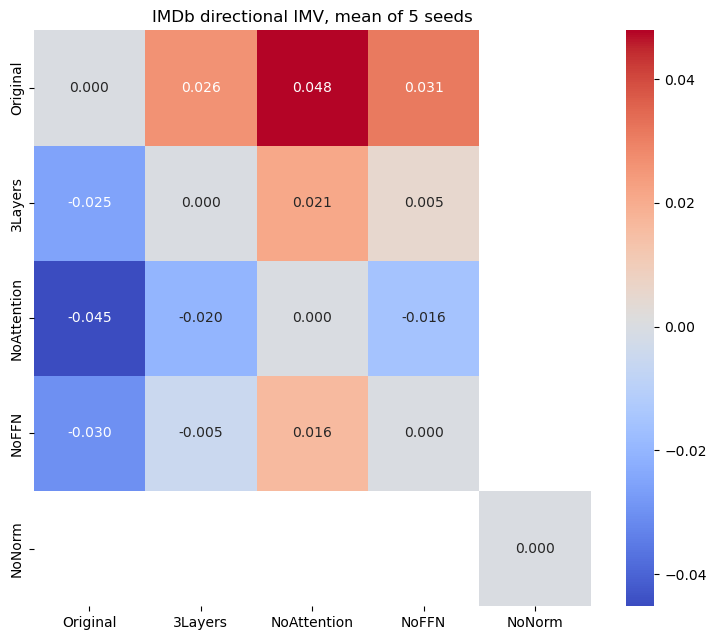

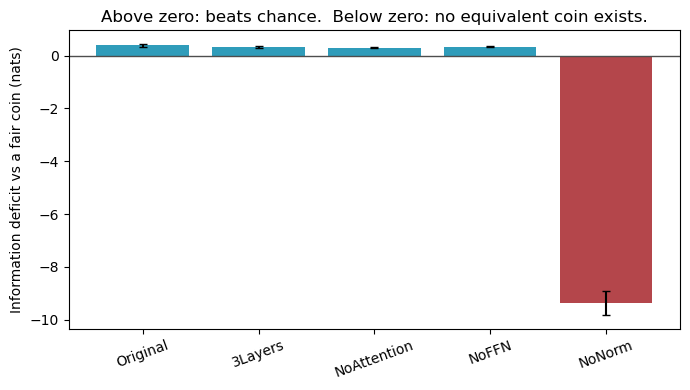

,mean,std
variant,,
Original,0.391652,0.050881
3Layers,0.340055,0.038275
NoAttention,0.302862,0.014229
NoFFN,0.329921,0.022443
NoNorm,-9.379645,0.448712


In [7]:
sound = [c for c in mean_matrix.columns if not mean_matrix[c].isna().all()]
fig, ax = plot_ablation_matrix(mean_matrix.loc[sound, sound], figsize=(7.5, 6.5),
                              title=f"IMDb directional IMV, mean of {len(SEEDS)} seeds")
fig.tight_layout()
matrix_paths = {file_format: relative_path(path, start=ARTIFACTS)
                for file_format, path in save_figure(
                    fig, FIGURES / "imdb_ablation_imv"
                ).items()}
plt.show()

# Variants with no equivalent coin cannot appear in an IMV matrix at all, so
# report how far below chance they fall, on an information scale.
fig2, ax2 = plt.subplots(figsize=(7, 4))
summary = diag.groupby("variant")["information_deficit_nats"].agg(["mean", "std"])
summary = summary.reindex(list(VARIANTS))
ax2.bar(summary.index, summary["mean"], yerr=summary["std"].fillna(0), capsize=3,
        color=["#2f9cba" if v >= 0 else "#b4464b" for v in summary["mean"]])
ax2.axhline(0, color="0.3", linewidth=1)
ax2.set_ylabel("Information deficit vs a fair coin (nats)")
ax2.set_title("Above zero: beats chance.  Below zero: no equivalent coin exists.")
ax2.tick_params(axis="x", rotation=20)
fig2.tight_layout()
deficit_paths = {file_format: relative_path(path, start=ARTIFACTS)
                 for file_format, path in save_figure(
                     fig2, FIGURES / "imdb_information_deficit"
                 ).items()}
plt.show()
summary
